# PyTorch DL for KDRIFT G1 Alignment

- EDA the training set
- Train using the baseline by the student's work

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
#import tensorflow as tf
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import Dense, SimpleRNN, Conv2D, MaxPooling2D, Flatten
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
#from tensorflow.keras import backend as K
from tqdm import trange, notebook
#from livelossplot import PlotLossesKeras



## Browsing the working directories

In [2]:
%pwd

'/app/kdrift/decenter_+-0.5mm,tilt_+-0.6deg/pytorch/notebook'

In [3]:
%ls

cnn-align-v1.ipynb  lightning_logs/


In [4]:
data_path = '/app/kdrift/decenter_+-0.5mm,tilt_+-0.6deg/pytorch/data/'

In [5]:
!ls {data_path}

X_f32.npy  y_f32.npy


## Explore the training set

In [6]:
%%time
X = np.load(data_path+'X_f32.npy')
y = np.load(data_path+'y_f32.npy')

CPU times: user 1.24 ms, sys: 223 ms, total: 224 ms
Wall time: 223 ms


In [7]:
len(y),len(X)

(20000, 20000)

In [8]:
def np_array_info(a):
    print(f"shape     : {a.shape}")
    print(f"dtype     : {a.dtype}")
    print(f"ndim      : {a.ndim}")
    print(f"size      : {a.size}")
    print(f"itemsize  : {a.itemsize} bytes")
    print(f"nbytes    : {a.nbytes / 1024**2:.2f} MB")
    print(f"min / max : {a.min()} / {a.max()}")

In [9]:
np_array_info(y)

shape     : (20000, 6)
dtype     : float32
ndim      : 2
size      : 120000
itemsize  : 4 bytes
nbytes    : 0.46 MB
min / max : -0.6000000238418579 / 0.6000000238418579


In [10]:
np_array_info(X)

shape     : (20000, 5, 64, 64, 1)
dtype     : float32
ndim      : 5
size      : 409600000
itemsize  : 4 bytes
nbytes    : 1562.50 MB
min / max : -44.47488021850586 / 41.380958557128906


> I may need learn about what `X` and `y` mean. I am an instrument noob. 

#### Visualize the training set

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def plot_trainingsample(X, y, selected_index_list):
    n_samples = len(selected_index_list)
    n_views = X.shape[1]

    fig, axes = plt.subplots(
        n_samples, n_views,
        figsize=(n_views * 2.2, n_samples * 2.2)
    )

    vmin, vmax = X.min(), X.max()
    im = None

    for row, idx in enumerate(selected_index_list):
        for j in range(n_views):
            ax = axes[row, j]
            img = X[idx, j, :, :, 0]

            im = ax.imshow(
                img,
                cmap="rainbow",
                vmin=vmin,
                vmax=vmax,
                aspect="equal"
            )

            ax.set_xticks([])
            ax.set_yticks([])

            if row == 0:
                ax.set_title(f"image {j+1}")

        # 🔹 y 값을 image 1 (j=0) 패널에 legend 형태로 표시
        if y is not None:
            yvals = y[idx]   # shape: (6,)

            labels = [f"y{i+1}: {val:.3f}" for i, val in enumerate(yvals)]

            # dummy handles for legend
            handles = [
                plt.Line2D([0], [0], color="none", label=lab)
                for lab in labels
            ]

            axes[row, 0].legend(
                handles=handles,
                loc="upper left",
                fontsize=8,
                frameon=True,
                borderpad=0.4,
                handlelength=0,
                handletextpad=0
            )

            # row identifier
            axes[row, 0].set_ylabel(f"idx {idx}")

    fig.subplots_adjust(
        bottom=0.12,
        hspace=0.05,
        wspace=0.02
    )

    fig.colorbar(
        im,
        ax=axes,
        orientation="horizontal",
        fraction=0.035,
        pad=0.02
    )

    plt.show()

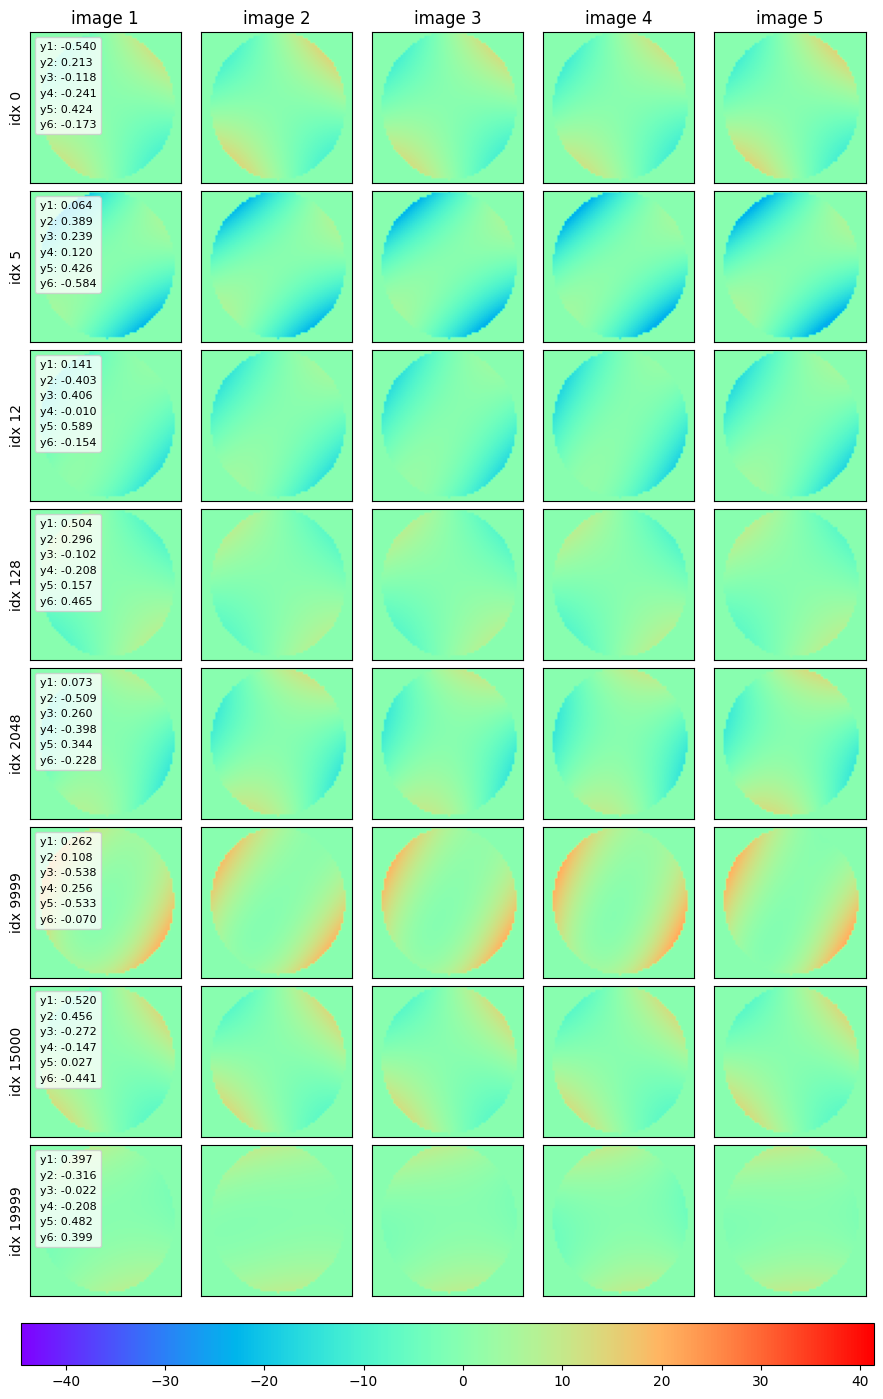

In [12]:
selected_index_list = [0, 5, 12, 128, 2048, 9999, 15000, 19999]
plot_trainingsample(X, y, selected_index_list)

## PyTorching the Model 

In [13]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
import pytorch_lightning as pl
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from torchvision import transforms
from torchvision.datasets import CIFAR10

In [14]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [15]:
# Get cpu, gpu or mps device for training.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [16]:
!nvidia-smi -L

GPU 0: NVIDIA GeForce RTX 3090 (UUID: GPU-81ef84f4-69df-ce9c-b89c-0b05c8f72ebf)


In [17]:
#%load_ext tensorboard
# I will not use tensorboard .. though..

In [18]:
# Setting the seed
pl.seed_everything(42)

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Seed set to 42


#### Checkpoints 

In [19]:
CHECKPOINT_ROOT = '/app/kdrift/decenter_+-0.5mm,tilt_+-0.6deg/pytorch/checkpoints/'

In [20]:
from time import gmtime, strftime

base_name = 'cnn'
#try_name = strftime('%Y.%m.%d_%H:%M', gmtime())
try_name = 'take1'
experiment_name = f"{base_name}_{try_name}"
print("experiment:", experiment_name)

experiment: cnn_take1


In [21]:
import os
import shutil

CHECKPOINT_PATH = os.path.join(CHECKPOINT_ROOT, experiment_name)

if os.path.exists(CHECKPOINT_PATH):
    print(f"⚠️ Directory exists: {CHECKPOINT_PATH}")
    print("🧹 Removing all contents...")

    # Clear all files/subfolders inside the directory
    for filename in os.listdir(CHECKPOINT_PATH):
        file_path = os.path.join(CHECKPOINT_PATH, filename)
        try:
            if os.path.isfile(file_path) or os.path.islink(file_path):
                os.unlink(file_path)
            elif os.path.isdir(file_path):
                shutil.rmtree(file_path)
        except Exception as e:
            print(f"❌ Failed to delete {file_path}: {e}")

    print("✅ Directory has been cleared.")
else:
    os.makedirs(CHECKPOINT_PATH)
    print(f"✅ Directory created: {CHECKPOINT_PATH}")

print(f"📂 Experiment directory is ready: {os.path.abspath(CHECKPOINT_PATH)}")

⚠️ Directory exists: /app/kdrift/decenter_+-0.5mm,tilt_+-0.6deg/pytorch/checkpoints/cnn_take1
🧹 Removing all contents...
✅ Directory has been cleared.
📂 Experiment directory is ready: /app/kdrift/decenter_+-0.5mm,tilt_+-0.6deg/pytorch/checkpoints/cnn_take1


### Follow the min/max/scaler of the original keras code for reproduction

In [22]:
num_samples = len(y)
print(num_samples)

20000


In [23]:
indices=range(num_samples)

In [24]:
X_train, X_test, y_train, y_test, train_indices, test_indices = \
train_test_split(X, y, indices, test_size=0.2, random_state=42)

In [25]:
%%time
X_train_train, X_train_val, \
y_train_train, y_train_val, \
train_train_indices, train_val_indices = \
    train_test_split(
        X_train,
        y_train,
        train_indices,
        test_size=0.2,
        random_state=42
    )

CPU times: user 66.5 ms, sys: 69.4 ms, total: 136 ms
Wall time: 134 ms


In [26]:
np_array_info(X_train_train)

shape     : (12800, 5, 64, 64, 1)
dtype     : float32
ndim      : 5
size      : 262144000
itemsize  : 4 bytes
nbytes    : 1000.00 MB
min / max : -44.47488021850586 / 38.766319274902344


In [27]:
np_array_info(X_train_val)

shape     : (3200, 5, 64, 64, 1)
dtype     : float32
ndim      : 5
size      : 65536000
itemsize  : 4 bytes
nbytes    : 250.00 MB
min / max : -40.51784896850586 / 41.380958557128906


In [28]:
np_array_info(X_test)

shape     : (4000, 5, 64, 64, 1)
dtype     : float32
ndim      : 5
size      : 81920000
itemsize  : 4 bytes
nbytes    : 312.50 MB
min / max : -38.55973815917969 / 38.85308074951172


In [29]:
train_indices[:12]

[5894, 3728, 8958, 7671, 5999, 5751, 1688, 6836, 6536, 4842, 15844, 196]

In [30]:
train_train_indices[:12]

[252, 18632, 19138, 1673, 17688, 8687, 17425, 11006, 4157, 3440, 1690, 5485]

In [31]:
train_val_indices[:12]

[17353, 16081, 8282, 1113, 9546, 9413, 7775, 9407, 964, 13581, 6553, 4659]

In [32]:
test_indices[:12]

[10650, 2041, 8668, 1114, 13902, 11963, 11072, 3002, 19771, 8115, 3525, 7879]

#### normalization by scaler

In [33]:
%%time
scaler = MinMaxScaler()
X_train_train_reshaped = X_train_train.reshape(-1, 64*64)
scaler.fit(X_train_train_reshaped)
X_train_train_scaled = scaler.transform(X_train_train_reshaped).reshape(-1, 5, 64, 64, 1)

CPU times: user 365 ms, sys: 43.6 ms, total: 409 ms
Wall time: 407 ms


In [34]:
X_train_val_reshaped = X_train_val.reshape(-1, 64*64)
scaler.fit(X_train_val_reshaped)
X_train_val_scaled = scaler.transform(X_train_val_reshaped).reshape(-1, 5, 64, 64, 1)

In [35]:
X_test_reshaped = X_test.reshape(-1, 64*64)
scaler.fit(X_test_reshaped)
X_test_scaled = scaler.transform(X_test_reshaped).reshape(-1, 5, 64, 64, 1)

In [36]:
np_array_info(X_train_train_scaled)

shape     : (12800, 5, 64, 64, 1)
dtype     : float32
ndim      : 5
size      : 262144000
itemsize  : 4 bytes
nbytes    : 1000.00 MB
min / max : 0.0 / 1.0000001192092896


In [37]:
np_array_info(X_train_val_scaled)

shape     : (3200, 5, 64, 64, 1)
dtype     : float32
ndim      : 5
size      : 65536000
itemsize  : 4 bytes
nbytes    : 250.00 MB
min / max : 0.0 / 1.0000001192092896


In [38]:
np_array_info(X_test_scaled)

shape     : (4000, 5, 64, 64, 1)
dtype     : float32
ndim      : 5
size      : 81920000
itemsize  : 4 bytes
nbytes    : 312.50 MB
min / max : 0.0 / 1.0000001192092896


In [39]:
np_array_info(y_train_train)

shape     : (12800, 6)
dtype     : float32
ndim      : 2
size      : 76800
itemsize  : 4 bytes
nbytes    : 0.29 MB
min / max : -0.6000000238418579 / 0.6000000238418579


In [40]:
np_array_info(y_train_val)

shape     : (3200, 6)
dtype     : float32
ndim      : 2
size      : 19200
itemsize  : 4 bytes
nbytes    : 0.07 MB
min / max : -0.6000000238418579 / 0.6000000238418579


In [41]:
np_array_info(y_test)

shape     : (4000, 6)
dtype     : float32
ndim      : 2
size      : 24000
itemsize  : 4 bytes
nbytes    : 0.09 MB
min / max : -0.6000000238418579 / 0.6000000238418579


In [42]:
import matplotlib.pyplot as plt
import numpy as np

def plot_y_histograms_splits(y_train_train, y_train_val, y_test, bins=50):
    """
    y_* shape: (N, 6)
    """

    fig, axes = plt.subplots(2, 3, figsize=(12, 7))
    axes = axes.ravel()

    # symmetric range across ALL splits
    all_y = np.concatenate([y_train_train, y_train_val, y_test], axis=0)
    vmin = all_y.min()
    vmax = all_y.max()
    vmax = max(abs(vmin), abs(vmax))
    hist_range = (-vmax, vmax)

    for i in range(6):
        ax = axes[i]

        ax.hist(
            y_train_train[:, i],
            bins=bins,
            range=hist_range,
            density=True,
            color='r',
            alpha=0.2,
            label="train"
        )
        ax.hist(
            y_train_val[:, i],
            bins=bins,
            range=hist_range,
            density=True,
            color='g',
            alpha=0.2,
            label="val"
        )
        ax.hist(
            y_test[:, i],
            bins=bins,
            range=hist_range,
            density=True,
            color='b',
            alpha=0.2,
            label="test"
        )

        ax.axvline(0, color="k", linestyle="--", linewidth=1)
        ax.set_title(f"y{i}")
        ax.set_xlabel("value")
        ax.set_ylabel("density")

        if i == 0:
            ax.legend()

    fig.suptitle("Distribution of y components (train / val / test)", fontsize=13)
    fig.tight_layout()
    plt.show()

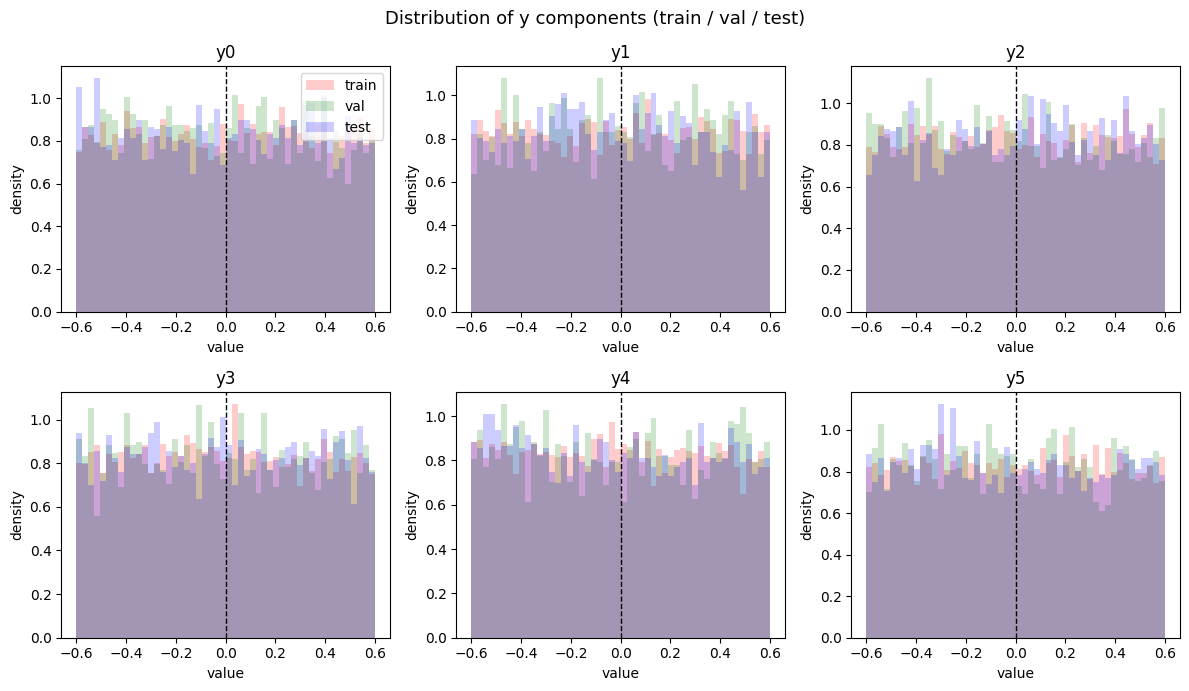

In [43]:
plot_y_histograms_splits(y_train_train, y_train_val, y_test)

## Train the CNN model

In [44]:
class CNNModelKerasEquivalent(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # Conv2D(32,(1,1), relu, input_shape=(5,64,64), channels_first)
            nn.Conv2d(in_channels=5, out_channels=32, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv2D(64,(3,3), relu)  (padding='valid' in Keras -> padding=0 in PyTorch)
            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Conv2D(32,(2,2), relu)
            nn.Conv2d(64, 32, kernel_size=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Conv2D(32,(1,1), relu)
            nn.Conv2d(32, 32, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Conv2D(32,(1,1), relu)
            nn.Conv2d(32, 32, kernel_size=1),
            nn.ReLU(inplace=True),

            nn.Flatten(),                 # Keras Flatten()
            nn.Linear(32 * 3 * 3, 128),   # 계산 결과: 64->32->30->15->14->7->3 => 32*3*3
            nn.ReLU(inplace=True),
            nn.Linear(128, 6)             # Dense(6)
        )

    def forward(self, x):
        return self.net(x)

In [45]:
from torch.utils.data import Dataset, DataLoader

class NumpyDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx]).float()  # (5,64,64)
        x = x.squeeze(-1) # if (5,64,64,1)
        t = torch.from_numpy(self.y[idx]).float()  # (6,)
        return x, t

In [46]:
train_ds = NumpyDataset(X_train_train, y_train_train)
val_ds   = NumpyDataset(X_train_val,   y_train_val)

In [47]:
x0, y0 = train_ds[0]
print(x0.shape)   # torch.Size([5, 64, 64])
print(y0.shape)   # torch.Size([6])

torch.Size([5, 64, 64])
torch.Size([6])


In [48]:
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

In [49]:
xb, yb = next(iter(train_loader))
print("xb.shape:", xb.shape)
print("yb.shape:", yb.shape)
print("xb.dtype:", xb.dtype)

xb.shape: torch.Size([32, 5, 64, 64])
yb.shape: torch.Size([32, 6])
xb.dtype: torch.float32


In [50]:
import time
import matplotlib.pyplot as plt
from pytorch_lightning.callbacks import Callback

class PlotLossesPL(Callback):
    def __init__(self):
        self.train_losses = []
        self.val_losses = []
        self.epoch_times = []

    def on_train_epoch_start(self, trainer, pl_module):
        self.epoch_start_time = time.time()

    def on_train_epoch_end(self, trainer, pl_module):
        epoch_time = time.time() - self.epoch_start_time
        self.epoch_times.append(epoch_time)

        train_loss = trainer.callback_metrics.get("train_loss")
        val_loss   = trainer.callback_metrics.get("val_loss")

        if train_loss is not None:
            self.train_losses.append(train_loss.item())
        if val_loss is not None:
            self.val_losses.append(val_loss.item())

        print(
            f"Epoch {trainer.current_epoch:03d} | "
            f"train MAE: {self.train_losses[-1]:.6f} | "
            f"val MAE: {self.val_losses[-1]:.6f} | "
            f"time: {epoch_time:.2f}s"
        )

    def on_fit_end(self, trainer, pl_module):
        self.plot()

    def plot(self):
        plt.figure(figsize=(6,4))
        plt.plot(self.train_losses, label="train")
        plt.plot(self.val_losses, label="val")
        plt.xlabel("epoch")
        plt.ylabel("MAE")
        plt.legend()
        plt.tight_layout()
        plt.show()

In [51]:
import time
from pytorch_lightning.callbacks import Callback

class GPUSleepCallback(Callback):
    def __init__(self, every_n_epochs=5, sleep_seconds=5):
        self.every_n_epochs = every_n_epochs
        self.sleep_seconds = sleep_seconds

    def on_train_epoch_end(self, trainer, pl_module):
        epoch = trainer.current_epoch + 1  # 1-based로 보기 좋게
        if epoch % self.every_n_epochs == 0:
            print(f"😴 Cooling GPU: sleeping {self.sleep_seconds}s after epoch {epoch}")
            time.sleep(self.sleep_seconds)

In [52]:
import os
from pytorch_lightning.callbacks import ModelCheckpoint

ckpt_dir = "/app/kdrift/decenter_+-0.5mm,tilt_+-0.6deg/pytorch/checkpoints/cnn_take1"
#ckpt_dir = CHECKPOINT_PATH

checkpoint_cb = ModelCheckpoint(
    dirpath=ckpt_dir,
    filename="best-{epoch:03d}-{val_loss:.6f}",  # 파일명 템플릿
    monitor="val_loss",                          # 우리가 log한 키
    mode="min",                                  # 최소가 best
    save_top_k=1,                                # best 1개만 유지
    save_last=True,                              # last.ckpt도 저장
    auto_insert_metric_name=False
)

In [53]:
import pytorch_lightning as pl
import torch
import torch.nn as nn

class LitCNN(pl.LightningModule):
    def __init__(self, model, lr=1e-3):
        super().__init__()
        self.model = model
        self.criterion = nn.L1Loss()
        self.lr = lr

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        self.log("train_loss", loss, prog_bar=False)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        self.log("val_loss", loss, prog_bar=False)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

In [54]:
from pytorch_lightning.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=100,
    mode="min"
)

In [55]:
from pytorch_lightning import Trainer

plot_cb = PlotLossesPL()
gpu_sleep_cb = GPUSleepCallback(every_n_epochs=5, sleep_seconds=5)

trainer = Trainer(
    max_epochs=200,
    callbacks=[plot_cb, checkpoint_cb, gpu_sleep_cb, early_stop],
    enable_progress_bar=False,
    enable_model_summary=False,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    log_every_n_steps=999999
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/loops/fit_loop.py:317: The number of training batches (400) is smaller than the logging interval Trainer(log_every_n_steps=999999). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 000 | train MAE: 0.086713 | val MAE: 0.090839 | time: 1.58s
Epoch 001 | train MAE: 0.086889 | val MAE: 0.088829 | time: 1.63s
Epoch 002 | train MAE: 0.082638 | val MAE: 0.081438 | time: 1.63s
Epoch 003 | train MAE: 0.060289 | val MAE: 0.078712 | time: 1.56s
Epoch 004 | train MAE: 0.093728 | val MAE: 0.080363 | time: 1.58s
😴 Cooling GPU: sleeping 5s after epoch 5
Epoch 005 | train MAE: 0.083063 | val MAE: 0.078651 | time: 1.58s
Epoch 006 | train MAE: 0.071067 | val MAE: 0.076489 | time: 1.62s
Epoch 007 | train MAE: 0.065431 | val MAE: 0.063293 | time: 1.57s
Epoch 008 | train MAE: 0.057928 | val MAE: 0.058170 | time: 1.60s
Epoch 009 | train MAE: 0.042449 | val MAE: 0.046684 | time: 1.65s
😴 Cooling GPU: sleeping 5s after epoch 10
Epoch 010 | train MAE: 0.041672 | val MAE: 0.038657 | time: 1.60s
Epoch 011 | train MAE: 0.033694 | val MAE: 0.026873 | time: 1.60s
Epoch 012 | train MAE: 0.028804 | val MAE: 0.026840 | time: 1.58s
Epoch 013 | train MAE: 0.030360 | val MAE: 0.029033 | time:

`Trainer.fit` stopped: `max_epochs=200` reached.


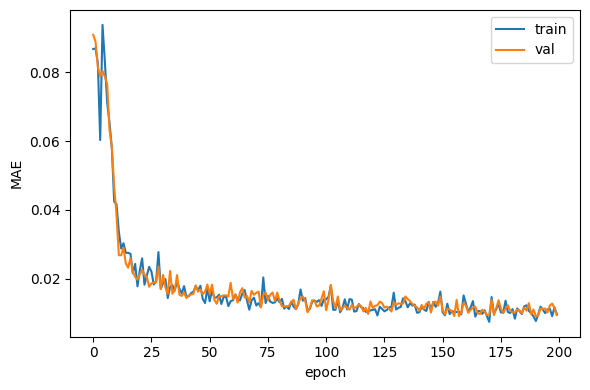

CPU times: user 5min 10s, sys: 1min 46s, total: 6min 56s
Wall time: 8min 41s


In [56]:
%%time
trainer.fit(
    model=LitCNN(CNNModelKerasEquivalent()),
    train_dataloaders=train_loader,
    val_dataloaders=val_loader
)

In [7]:
len(y)

20000

In [8]:
indices=range(num_samples)

In [9]:
X_train, X_test, y_train, y_test, train_indices, test_indices = \
train_test_split(X, y, indices, test_size=0.2, random_state=42)

In [10]:
scaler = MinMaxScaler()
X_train_reshaped = X_train.reshape(-1, 64*64)
scaler.fit(X_train_reshaped)
X_train_scaled = scaler.transform(X_train_reshaped).reshape(-1, 5, 64, 64, 1)


In [11]:
X_train_scaled[2][3][4][30]

array([0.45657826])

In [38]:
## save scaling method
from pickle import dump
dump(scaler,open('./MinMaxScaler.pkl','wb'))

## 2DConv

In [16]:
cnn_model = Sequential([
    Conv2D(32,(1,1), activation='relu',input_shape=(5,64,64),data_format='channels_first'),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(32,(2,2),activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(32,(1,1),activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(32,(1,1),activation='relu'),
    Flatten(),
    Dense(128,activation = 'relu'),
    Dense(6)
    ])

In [17]:
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 32, 64, 64)     │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 30, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 15, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 14, 32)      │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 3, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 7, 32)       │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 1, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 1, 3, 32)       │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,646 (236.90 KB)

 Trainable params: 60,646 (236.90 KB)

 Non-trainable params: 0 (0.00 B)

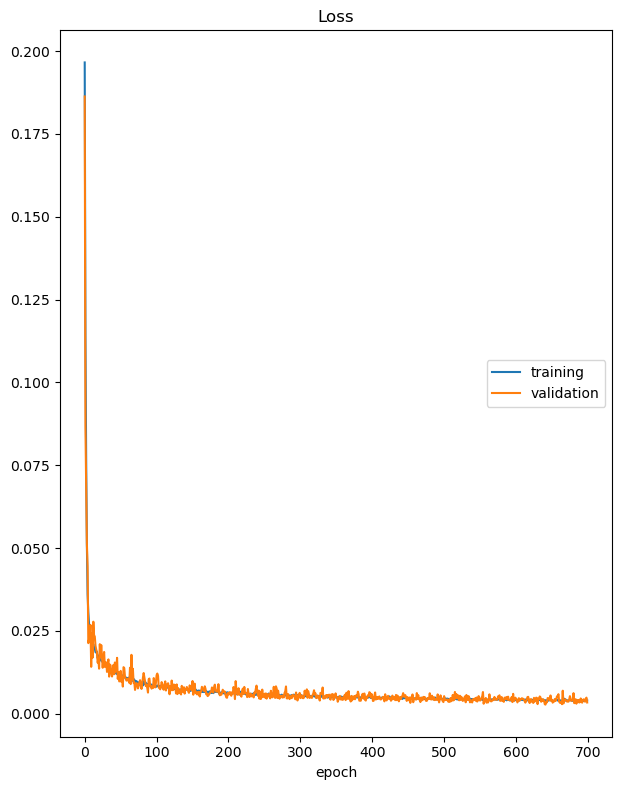

Loss
	training         	 (min:    0.004, max:    0.197, cur:    0.004)
	validation       	 (min:    0.003, max:    0.186, cur:    0.003)
400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 0.0042 - val_loss: 0.0034


In [18]:
cnn_model.compile(optimizer='adam', loss='mae')
cnn_model.fit(X_train_scaled, y_train, epochs=700, batch_size=32, validation_split=0.2, callbacks=[PlotLossesKeras()])

In [19]:
X_test_reshaped = X_test.reshape(-1, 64*64)
X_test_scaled = scaler.transform(X_test_reshaped).reshape(-1, 5, 64, 64, 1)

In [25]:
model_cnn_eval = cnn_model.evaluate(X_test_scaled, y_test)

print(f'Model MAE :{model_cnn_eval}')

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0033
Model MAE :0.0033780941739678383


In [28]:
model_predic = cnn_model.predict(X_test_scaled)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [29]:
from keras.models import load_model
import keras
keras.saving.save_model(cnn_model, 'cnn_2d.keras')

In [30]:
for i in range(5):
    print(f'Sample {i+1}:')
    print(f'Actual Errors: {y_test[i]}')
    print(f'Predicted Errors: {model_predic[i]}')
    print()

Sample 1:
Actual Errors: [-0.176 -0.427 -0.465  0.038 -0.409  0.21 ]
Predicted Errors: [-0.17832516 -0.43063936 -0.46807566  0.03895595 -0.40938872  0.21080579]

Sample 2:
Actual Errors: [ 0.029  0.102  0.058  0.599  0.536 -0.324]
Predicted Errors: [ 0.03370278  0.10325056  0.06709035  0.59949476  0.53160155 -0.32155064]

Sample 3:
Actual Errors: [ 0.347  0.286  0.568  0.571 -0.246  0.572]
Predicted Errors: [ 0.34461507  0.2940309   0.56543285  0.5655657  -0.24760444  0.57693344]

Sample 4:
Actual Errors: [-0.109  0.135 -0.532 -0.227  0.355 -0.463]
Predicted Errors: [-0.11037649  0.12794387 -0.5282384  -0.22283944  0.3529094  -0.466952  ]

Sample 5:
Actual Errors: [-0.148  0.2    0.031  0.272  0.088 -0.339]
Predicted Errors: [-0.14649129  0.20090973  0.03500868  0.27110535  0.08537021 -0.3374838 ]



## 결과저장

In [31]:
test_indices

[10650,
 2041,
 8668,
 1114,
 13902,
 11963,
 11072,
 3002,
 19771,
 8115,
 3525,
 7879,
 16441,
 16296,
 12566,
 5252,
 19393,
 16796,
 8094,
 322,
 9923,
 7459,
 19024,
 17553,
 9119,
 16421,
 16060,
 10120,
 19055,
 3649,
 3941,
 17880,
 16675,
 12630,
 11443,
 12157,
 13835,
 3434,
 18739,
 17407,
 15440,
 10406,
 6517,
 971,
 16487,
 19730,
 13137,
 3669,
 15983,
 4058,
 14976,
 15698,
 13829,
 13419,
 960,
 17744,
 9864,
 11263,
 15782,
 17196,
 7554,
 10498,
 17059,
 17928,
 7085,
 14753,
 4519,
 3024,
 12121,
 18494,
 5483,
 1419,
 6209,
 10742,
 16143,
 17617,
 14568,
 980,
 2783,
 7713,
 11518,
 8600,
 11640,
 18830,
 12562,
 12751,
 6384,
 4807,
 6195,
 10648,
 7567,
 16397,
 17524,
 1346,
 13124,
 12673,
 15455,
 14001,
 18621,
 2119,
 15304,
 4309,
 4484,
 11013,
 4770,
 2712,
 12186,
 16615,
 10947,
 2545,
 12619,
 9851,
 4410,
 19647,
 12344,
 12407,
 9610,
 10718,
 7571,
 3570,
 8602,
 3559,
 4991,
 7439,
 9325,
 2300,
 7666,
 5804,
 12022,
 15537,
 9757,
 12014,
 5211,

In [32]:
predicted_file_number = []
for i in range(len(test_indices)) :
    a = test_indices[i] + 1
    b = str(a)
    predicted_file_number.append(b)

In [33]:
predicted_file_number

['10651',
 '2042',
 '8669',
 '1115',
 '13903',
 '11964',
 '11073',
 '3003',
 '19772',
 '8116',
 '3526',
 '7880',
 '16442',
 '16297',
 '12567',
 '5253',
 '19394',
 '16797',
 '8095',
 '323',
 '9924',
 '7460',
 '19025',
 '17554',
 '9120',
 '16422',
 '16061',
 '10121',
 '19056',
 '3650',
 '3942',
 '17881',
 '16676',
 '12631',
 '11444',
 '12158',
 '13836',
 '3435',
 '18740',
 '17408',
 '15441',
 '10407',
 '6518',
 '972',
 '16488',
 '19731',
 '13138',
 '3670',
 '15984',
 '4059',
 '14977',
 '15699',
 '13830',
 '13420',
 '961',
 '17745',
 '9865',
 '11264',
 '15783',
 '17197',
 '7555',
 '10499',
 '17060',
 '17929',
 '7086',
 '14754',
 '4520',
 '3025',
 '12122',
 '18495',
 '5484',
 '1420',
 '6210',
 '10743',
 '16144',
 '17618',
 '14569',
 '981',
 '2784',
 '7714',
 '11519',
 '8601',
 '11641',
 '18831',
 '12563',
 '12752',
 '6385',
 '4808',
 '6196',
 '10649',
 '7568',
 '16398',
 '17525',
 '1347',
 '13125',
 '12674',
 '15456',
 '14002',
 '18622',
 '2120',
 '15305',
 '4310',
 '4485',
 '11014',
 '477

In [34]:
with open('D:/third_trial/data/predicted_file_number.txt','w') as file :
    for i in predicted_file_number :
        file.write(i+'\n')


In [35]:
a = list(model_predic[0])
a

[-0.17832516, -0.43063936, -0.46807566, 0.038955946, -0.40938872, 0.21080579]

In [36]:
for i in range(len(predicted_file_number)) :
    file_path = 'D:/third_trial/data/data' + predicted_file_number[i] + '/predicted_error.txt'
    error = list(model_predic[i])
    with open(file_path,'w') as f :
        for item in error :
            f.write(str(item) + '\n')